# Deep Learning Experiment: Image Classification on Fashion-MNIST

**Author:** Sébastien Bodrero
**Programme:** MSc in Artificial Intelligence — Woolf University / Udacity
**Module 4:** Deep Learning Systems
**Date:** April 2026

---

This notebook implements a deep learning experiment workflow for image classification using the **Fashion-MNIST** dataset (70,000 grayscale 28×28 images, 10 clothing categories). A **Convolutional Neural Network (CNN)** is the natural choice for this task: CNNs exploit spatial structure through local receptive fields and weight sharing, making them highly parameter-efficient for image data compared to fully connected networks (LeCun et al., 1998).

The experiment compares two configurations:
- **Baseline SimpleCNN** — two convolutional blocks + two fully connected layers, no regularization
- **CNN + Dropout** — identical architecture with `Dropout(p=0.5)` applied after the first fully connected layer

The notebook follows six structured sections:

1. **Setup** — imports and device configuration
2. **Dataset & Preprocessing** — data loading, normalization, visualization
3. **Baseline Model** — SimpleCNN architecture, training, loss curve
4. **Experimental Model** — CNN + Dropout, training, loss curve
5. **Evaluation & Comparison** — test accuracy, confusion matrix, example predictions
6. **Notebook Summary** — findings and limitations

## 1. Setup

In [2]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
import torchvision
import torchvision.transforms as transforms

import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report

import warnings
warnings.filterwarnings('ignore')

# Reproducibility
torch.manual_seed(42)
np.random.seed(42)

# Device configuration — runs on CPU if no GPU available
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 100

print(f'PyTorch      {torch.__version__}')
print(f'torchvision  {torchvision.__version__}')
print(f'NumPy        {np.__version__}')
print(f'Matplotlib   {matplotlib.__version__}')
print(f'Device       {DEVICE}')

PyTorch      2.11.0
torchvision  0.26.0
NumPy        2.4.4
Matplotlib   3.10.8
Device       cpu


## 2. Dataset & Preprocessing

**Fashion-MNIST** (Xiao et al., 2017) is a drop-in replacement for MNIST containing 70,000 grayscale 28×28 images of clothing items across 10 classes. It is distributed by Zalando Research and is publicly available via `torchvision.datasets`. The dataset is downloaded automatically on first run into a local `data/` directory.

| Split | Samples |
|-------|---------|
| Training | 60,000 |
| Test | 10,000 |

**Preprocessing:** Images are converted to tensors and normalized using the dataset's population statistics (mean = 0.2860, std = 0.3530). Normalization is standard practice for neural network training: it centers the input distribution, accelerates gradient-based optimization, and reduces sensitivity to initial weight scale.

In [3]:
CLASS_NAMES = [
    'T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat',
    'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot'
]

# Normalization constants computed from the FashionMNIST training set
FMNIST_MEAN = (0.2860,)
FMNIST_STD  = (0.3530,)

transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(FMNIST_MEAN, FMNIST_STD)
])

train_dataset = torchvision.datasets.FashionMNIST(
    root='./data', train=True, download=True, transform=transform
)
test_dataset = torchvision.datasets.FashionMNIST(
    root='./data', train=False, download=True, transform=transform
)

BATCH_SIZE = 64
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True,  num_workers=0)
test_loader  = DataLoader(test_dataset,  batch_size=BATCH_SIZE, shuffle=False, num_workers=0)

print(f'Training samples : {len(train_dataset):,}')
print(f'Test samples     : {len(test_dataset):,}')
print(f'Batch size       : {BATCH_SIZE}')
print(f'Training batches : {len(train_loader)}')
print(f'Classes          : {CLASS_NAMES}')

100.0%
100.0%
100.0%
100.0%


Training samples : 60,000
Test samples     : 10,000
Batch size       : 64
Training batches : 938
Classes          : ['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat', 'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']


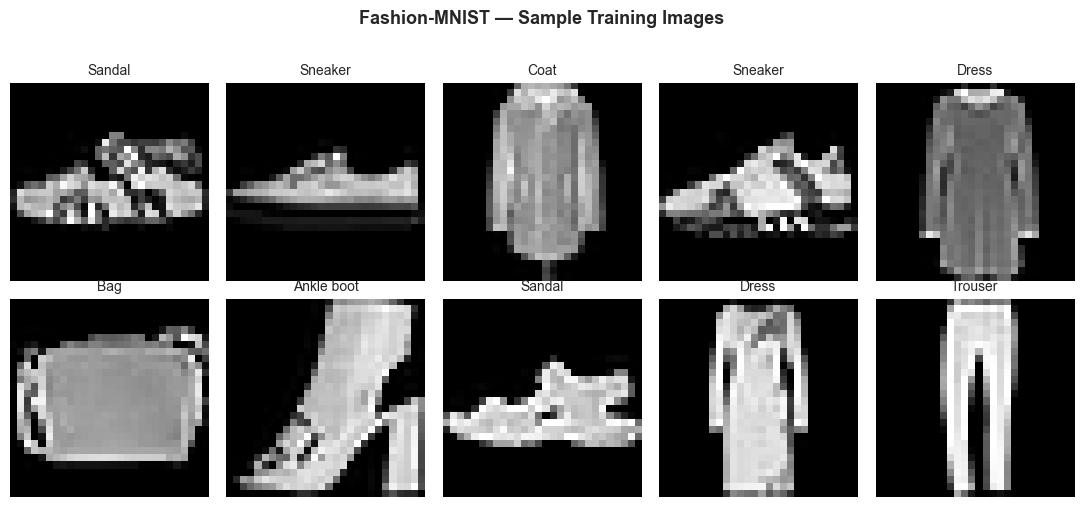

In [4]:
# Display 10 sample images from the training set
images, labels = next(iter(train_loader))

# Denormalize for display
def denorm(img_tensor):
    """Reverse normalization for display purposes."""
    return img_tensor * FMNIST_STD[0] + FMNIST_MEAN[0]

fig, axes = plt.subplots(2, 5, figsize=(11, 5))
for i, ax in enumerate(axes.flat):
    img = denorm(images[i].squeeze())
    ax.imshow(img.numpy(), cmap='gray')
    ax.set_title(CLASS_NAMES[labels[i].item()], fontsize=10)
    ax.axis('off')

fig.suptitle('Fashion-MNIST — Sample Training Images', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

## 3. Baseline Model — SimpleCNN

### Architecture

The baseline is a straightforward two-block CNN:

| Layer | Configuration | Output shape |
|-------|---------------|--------------|
| Conv1 | 1→32 filters, 3×3, padding=1, ReLU | 32×28×28 |
| MaxPool | 2×2 | 32×14×14 |
| Conv2 | 32→64 filters, 3×3, padding=1, ReLU | 64×14×14 |
| MaxPool | 2×2 | 64×7×7 |
| Flatten | — | 3,136 |
| FC1 | 3,136→256, ReLU | 256 |
| FC2 | 256→10 (logits) | 10 |

**Design rationale:** Two convolutional blocks are sufficient for 28×28 images — deeper networks would not have meaningful spatial extent to exploit. ReLU activations prevent vanishing gradients. Max-pooling provides translation invariance and reduces spatial dimensions by 2× at each stage. The FC layers map the learned feature representation to the 10-class output.

**Training configuration:** Adam optimizer (lr = 0.001, default β₁ = 0.9, β₂ = 0.999), CrossEntropyLoss, 10 epochs.

In [5]:
class SimpleCNN(nn.Module):
    """Baseline CNN for Fashion-MNIST classification.

    Two convolutional blocks (conv + ReLU + MaxPool) followed by
    two fully connected layers. No regularization.

    Parameters
    ----------
    num_classes : int
        Number of output classes (default: 10).
    """
    def __init__(self, num_classes: int = 10):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(1, 32, kernel_size=3, padding=1), nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Conv2d(32, 64, kernel_size=3, padding=1), nn.ReLU(),
            nn.MaxPool2d(2),
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(64 * 7 * 7, 256), nn.ReLU(),
            nn.Linear(256, num_classes)
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.classifier(self.features(x))


baseline = SimpleCNN().to(DEVICE)
total_params = sum(p.numel() for p in baseline.parameters() if p.requires_grad)
print(baseline)
print(f'\nTrainable parameters: {total_params:,}')

SimpleCNN(
  (features): Sequential(
    (0): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): ReLU()
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=3136, out_features=256, bias=True)
    (2): ReLU()
    (3): Linear(in_features=256, out_features=10, bias=True)
  )
)

Trainable parameters: 824,458


In [6]:
def train_model(model, train_loader, test_loader, epochs, lr, device, label):
    """Train a PyTorch model and track loss and accuracy per epoch.

    Parameters
    ----------
    model : nn.Module
        Initialised PyTorch model.
    train_loader : DataLoader
        Training data loader.
    test_loader : DataLoader
        Validation/test data loader used for per-epoch accuracy.
    epochs : int
        Number of training epochs.
    lr : float
        Adam learning rate.
    device : torch.device
        CPU or CUDA device.
    label : str
        Display name for progress output.

    Returns
    -------
    tuple[list[float], list[float]]
        Per-epoch training losses and test accuracies.
    """
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=lr)
    train_losses, test_accs = [], []

    for epoch in range(1, epochs + 1):
        # --- Training ---
        model.train()
        running_loss = 0.0
        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            running_loss += loss.item() * images.size(0)

        epoch_loss = running_loss / len(train_loader.dataset)
        train_losses.append(epoch_loss)

        # --- Validation ---
        model.eval()
        correct, total = 0, 0
        with torch.no_grad():
            for images, labels in test_loader:
                images, labels = images.to(device), labels.to(device)
                outputs = model(images)
                _, predicted = outputs.max(1)
                total += labels.size(0)
                correct += predicted.eq(labels).sum().item()

        acc = correct / total
        test_accs.append(acc)
        print(f'[{label}] Epoch {epoch:2d}/{epochs} | Loss: {epoch_loss:.4f} | Test Acc: {acc:.4f}')

    return train_losses, test_accs


EPOCHS = 10
LR     = 0.001

print('=== Training Baseline SimpleCNN ===')
baseline_losses, baseline_accs = train_model(
    baseline, train_loader, test_loader,
    epochs=EPOCHS, lr=LR, device=DEVICE, label='Baseline'
)


=== Training Baseline SimpleCNN ===
[Baseline] Epoch  1/10 | Loss: 0.4009 | Test Acc: 0.8924
[Baseline] Epoch  2/10 | Loss: 0.2541 | Test Acc: 0.9025
[Baseline] Epoch  3/10 | Loss: 0.2068 | Test Acc: 0.9088
[Baseline] Epoch  4/10 | Loss: 0.1768 | Test Acc: 0.9051
[Baseline] Epoch  5/10 | Loss: 0.1476 | Test Acc: 0.9171
[Baseline] Epoch  6/10 | Loss: 0.1229 | Test Acc: 0.9194
[Baseline] Epoch  7/10 | Loss: 0.0998 | Test Acc: 0.9153
[Baseline] Epoch  8/10 | Loss: 0.0832 | Test Acc: 0.9154
[Baseline] Epoch  9/10 | Loss: 0.0639 | Test Acc: 0.9141
[Baseline] Epoch 10/10 | Loss: 0.0535 | Test Acc: 0.9155


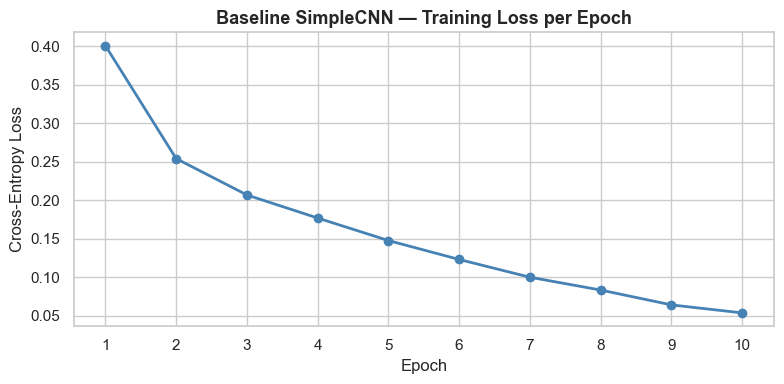

Final baseline test accuracy: 0.9155


In [7]:
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(range(1, EPOCHS + 1), baseline_losses, marker='o', color='steelblue', linewidth=2)
ax.set_title('Baseline SimpleCNN — Training Loss per Epoch', fontsize=13, fontweight='bold')
ax.set_xlabel('Epoch', fontsize=12)
ax.set_ylabel('Cross-Entropy Loss', fontsize=12)
ax.set_xticks(range(1, EPOCHS + 1))
plt.tight_layout()
plt.show()
print(f'Final baseline test accuracy: {baseline_accs[-1]:.4f}')